In [2]:
import sys
import os

# Add the root path (2 levels up) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

In [17]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [18]:
class CustomDataset(Dataset):
    def __init__(self, csv_file, transform=None, has_labels=True):
        # Load CSV file
        df = pd.read_csv(csv_file)
        self.has_labels = has_labels

        # Extract pixels and labels (if available)
        if has_labels:
            self.labels = df['label'].values
            self.images = df.drop(columns=['label']).values
        else:
            self.images = df.values
            self.labels = np.zeros(len(self.images))  # Dummy labels

        # Reshape images to [N, 1, 28, 28] and normalize to [0, 1]
        self.images = self.images.reshape(-1, 1, 28, 28).astype(np.float32) / 255.0
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # Convert to tensor
        image = torch.tensor(image, dtype=torch.float32)
        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_csv_path = '../../Convolutional_NeuralNetwork/train.csv' 
train_dataset = CustomDataset(csv_file=train_csv_path, has_labels=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=256, shuffle=True)

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(AutoEncoder, self).__init__()
        self.latent_dim = latent_dim

        # Encoder: Conv layers + Linear to latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # [batch, 1, 28, 28] -> [batch, 16, 28, 28]
            nn.ReLU(),
            nn.BatchNorm2d(16),  # Stabilizes gradients
            nn.MaxPool2d(2, 2),  # [batch, 16, 28, 28] -> [batch, 16, 14, 14]
            nn.Conv2d(16, 8, kernel_size=3, padding=1),  # [batch, 16, 14, 14] -> [batch, 8, 14, 14]
            nn.ReLU(),
            nn.BatchNorm2d(8),
            nn.MaxPool2d(2, 2),  # [batch, 8, 14, 14] -> [batch, 8, 7, 7]
            nn.Flatten(),  # [batch, 8*7*7] = [batch, 392]
            nn.Linear(8 * 7 * 7, latent_dim),  # [batch, 392] -> [batch, latent_dim]
            nn.ReLU()
        )

        # Decoder: Linear to feature map + ConvTranspose layers
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8 * 7 * 7),  # [batch, latent_dim] -> [batch, 392]
            nn.ReLU(),
            nn.Unflatten(1, (8, 7, 7)),  # [batch, 392] -> [batch, 8, 7, 7]
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # [batch, 8, 7, 7] -> [batch, 16, 14, 14]
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),  # [batch, 16, 14, 14] -> [batch, 8, 28, 28]
            nn.ReLU(),
            nn.BatchNorm2d(8),
            nn.Conv2d(8, 1, kernel_size=3, padding=1),  # [batch, 8, 28, 28] -> [batch, 1, 28, 28]
            nn.Sigmoid()  # Output in [0, 1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AutoEncoder(latent_dim=32).to(device)
criterion = nn.BCELoss()  # Binary cross-entropy for [0, 1] outputs
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for data in train_loader:
        images, _ = data  # Ignore labels
        images = images.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, images)

        # Backward pass with gradient clipping
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Prevent gradient explosion
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')

Epoch [1/50], Loss: 0.3702
Epoch [2/50], Loss: 0.1388
Epoch [3/50], Loss: 0.1179
Epoch [4/50], Loss: 0.1110
Epoch [5/50], Loss: 0.1071
Epoch [6/50], Loss: 0.1045
Epoch [7/50], Loss: 0.1024
Epoch [8/50], Loss: 0.1011
Epoch [9/50], Loss: 0.1000
Epoch [10/50], Loss: 0.0987
Epoch [11/50], Loss: 0.0978
Epoch [12/50], Loss: 0.0970
Epoch [13/50], Loss: 0.0968
Epoch [14/50], Loss: 0.0958
Epoch [15/50], Loss: 0.0954
Epoch [16/50], Loss: 0.0950
Epoch [17/50], Loss: 0.0943
Epoch [18/50], Loss: 0.0942
Epoch [19/50], Loss: 0.0936
Epoch [20/50], Loss: 0.0933
Epoch [21/50], Loss: 0.0931
Epoch [22/50], Loss: 0.0927
Epoch [23/50], Loss: 0.0925
Epoch [24/50], Loss: 0.0923
Epoch [25/50], Loss: 0.0920
Epoch [26/50], Loss: 0.0919
Epoch [27/50], Loss: 0.0917
Epoch [28/50], Loss: 0.0914
Epoch [29/50], Loss: 0.0914
Epoch [30/50], Loss: 0.0914
Epoch [31/50], Loss: 0.0908
Epoch [32/50], Loss: 0.0909
Epoch [33/50], Loss: 0.0910
Epoch [34/50], Loss: 0.0905
Epoch [35/50], Loss: 0.0904
Epoch [36/50], Loss: 0.0903
E

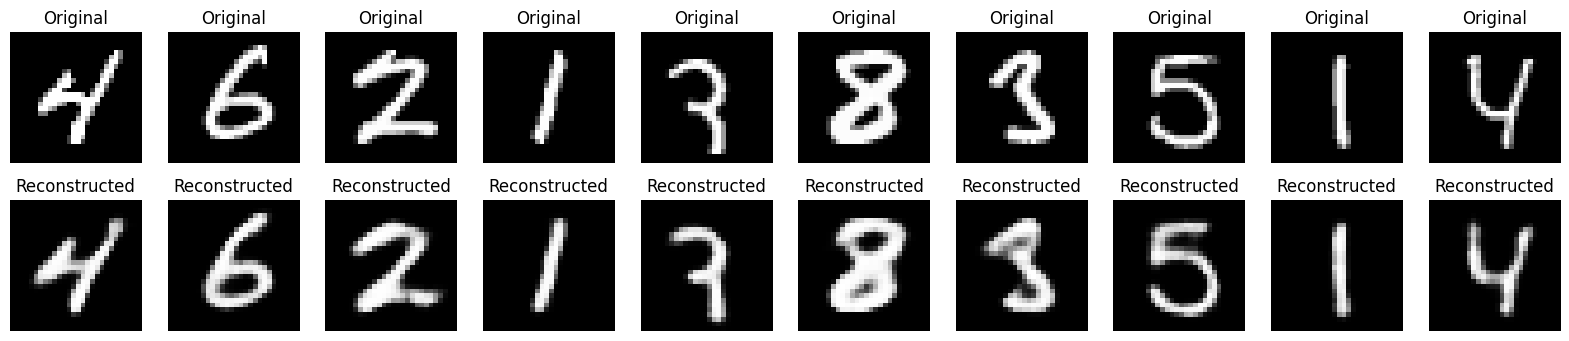

In [21]:
model.eval()
with torch.no_grad():
    test_images, _ = next(iter(train_loader))
    test_images = test_images.to(device)
    reconstructed = model(test_images)

    n = 10
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(test_images[i].cpu().squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    plt.show()